# Plotting NRH radio images of the Sun

Load cleaned Nançay Radioheliograph (NRH) images stored as IDL `.sav` files,
convert them to `sunpy` maps, and produce publication-quality figures and movies.

**Workflow**
1. Load NRH images for one frequency channel on a given day.
2. Optionally load several frequency channels at once.
3. Convert the images to `sunpy` maps.
4. Draw the synthesised beam (bottom-left corner) — toggleable.
5. Plot the NRH map for a chosen frame / timestamp.
6. Download the matching AIA 193 A map (`Fido`) at the same timestamp.
7. Overplot NRH contours on AIA (single and multiple frequencies).
8. Export an NRH-contour movie for a single frequency over time (MP4).
9. Export an NRH-contour movie for multiple frequencies over time (MP4).

Each `.sav` file holds one frequency channel: `nrh_data` is a `(n_time, ny, nx)`
cube and `nrh_hdr` is a per-frame header record array. The beam is **not** in the
header, so its measured major/minor axes are provided in the config below.


In [38]:
import warnings
warnings.filterwarnings('ignore')

import os
import glob

import numpy as np
import pandas as pd
from datetime import timedelta

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
from matplotlib.patches import Ellipse
from matplotlib.animation import FFMpegWriter

import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.visualization import (ImageNormalize, SqrtStretch, AsinhStretch,
                                   LogStretch, PowerStretch)

import sunpy.map
from sunpy.net import Fido, attrs as a
from sunpy.coordinates import frames
from sunpy.time import parse_time

from scipy.io import readsav
from tqdm import tqdm

# Reproducibility
seed_val = 7
os.environ['PYTHONHASHSEED'] = str(seed_val)
import random; random.seed(seed_val)
np.random.seed(seed_val)

## Plotting parameters

All figure styling lives here — change once, applies everywhere. Nothing below
hardcodes font sizes, DPI or colours.


In [39]:
# Figure geometry / resolution
FIGSIZE   = (7, 7)
DPI       = 100        # on-screen / movie dpi
SAVE_DPI  = 100        # static figure export dpi

# Font sizes
FONTSIZE        = 11   # base
TITLE_FONTSIZE  = 13
LABEL_FONTSIZE  = 11
TICK_FONTSIZE   = 10
LEGEND_FONTSIZE = 9
ANNOT_FONTSIZE  = 10   # the "frame = ..." overlay text

# Colours / colormaps
CMAP         = 'RdYlBu_r'   # NRH image colormap
CONTOUR_CMAP = 'Blues'      # single-frequency contour colormap
AIA_CMAP     = 'Greys'
LIMB_COLOR   = 'w'
# One colormap per frequency for the multi-frequency overlays
FREQ_CMAPS = ['YlGnBu', 'Reds', 'Oranges', 'Greens', 'Blues', 'Purples',
              'Greys', 'spring', 'cool', 'autumn']

plt.rcParams.update({
    'figure.figsize':   FIGSIZE,
    'figure.dpi':       DPI,
    'savefig.dpi':      SAVE_DPI,
    'figure.facecolor': 'white',
    'savefig.facecolor':'white',
    'savefig.format':   'png',
    'font.size':        FONTSIZE,
    'axes.titlesize':   TITLE_FONTSIZE,
    'axes.labelsize':   LABEL_FONTSIZE,
    'xtick.labelsize':  TICK_FONTSIZE,
    'ytick.labelsize':  TICK_FONTSIZE,
    'legend.fontsize':  LEGEND_FONTSIZE,
})

## Configuration

Observation, frame selection, beam geometry and normalisation options.


In [58]:
# --- Observation / paths --------------------------------------------------
mydate   = '20251006'                      # day to analyse (YYYYMMDD)
data_dir = f'/home/mnedal/data/NRH/{mydate}'
savedir  = f'{data_dir}/output'            # where figures / movies are written
os.makedirs(savedir, exist_ok=True)

# --- Frame / timestamp selection ------------------------------------------
TS = '2025-10-06T08:58:38'   # primary selection: NRH frame closest to this time
freq_index = 0               # which frequency file (0 = lowest listed)

# --- Contours -------------------------------------------------------------
CONTOUR_LEVELS = np.arange(70, 100, 10) * u.percent

# --- AIA ------------------------------------------------------------------
AIA_CHANNEL = 193            # Angstrom

# --- Beam display ---------------------------------------------------------
SHOW_BEAM = True             # master on/off switch for the beam ellipse
BEAM_LOC  = 'measured'       # 'measured' (use endpoint coords) or 'corner'

# --- Intensity normalisation across time ----------------------------------
GLOBAL_NORM      = True          # same vmin/vmax for every frame of a cube
VLIM_PERCENTILES = (1.0, 99.5)   # robust limits from the cube
VLIM_SAMPLE_STEP = 20            # subsample frames when computing the limits
NORM_KIND        = 'power'      # 'linear' | 'log' | 'sqrt' | 'power' | 'asinh'
NORM_KWARGS      = {}            # e.g. {'gamma': 0.5} for power, {'a': 0.1} for asinh

# --- Movies ---------------------------------------------------------------
MOVIE_FRAME_STEP = 1         # 1 = every frame, full resolution (no downsampling). Or subsample cube for movies (240 -> 1 frame/s)
MOVIE_FPS        = 20        # playback rate (all frames are kept)
MOVIE_DPI        = 150       # raster resolution per frame (raise for sharper output)
MOVIE_AXES_RECT  = (0.13, 0.11, 0.80, 0.82)  # fixed axes box -> identical frame sizes

sav_files = sorted(glob.glob(f'{data_dir}/*.sav'))
print(f'{len(sav_files)} frequency files found:')
print(*sav_files, sep='\n')

10 frequency files found:
/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_150_9.sav
/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_173_2.sav
/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_228_0.sav
/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_270_6.sav
/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_298_7.sav
/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_327_0.sav
/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_382_2.sav
/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_408_0.sav
/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_432_0.sav
/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_444_0.sav


### Measured beam geometry

The synthesised beam is not stored in the `.sav` headers. These are the
major/minor axis endpoints (arcsec, helioprojective) measured by hand per
frequency. The full axis length is the distance between endpoints; the beam
position angle is taken from the major-axis endpoints. Frequencies are matched
to the nearest key within `BEAM_FREQ_TOL` MHz; channels without an entry simply
get no beam drawn.


In [41]:
RSUN_ARCSEC_REF = 954.66  # 959.5 # reference solar radius used for the Rs print-outs
BEAM_FREQ_TOL   = 2       # MHz tolerance when matching a channel to a beam entry

# {freq_MHz: {'major': (x1, y1, x2, y2), 'minor': (x1, y1, x2, y2)}}  in arcsec
BEAM_AXES = {
    150.9: {'major': (-1830, -1810, -1400, -1550), 'minor': (-1668, -1608, -1548, -1772)},
    173.2: {'major': (-1810, -1810, -1450, -1580), 'minor': (-1682, -1638, -1562, -1772)},
    228.0: {'major': (-1830, -1810, -1550, -1640), 'minor': (-1728, -1682, -1638, -1788)},
    298.7: {'major': (-1830, -1830, -1610, -1700), 'minor': (-1742, -1728, -1698, -1801)},
    327.5: {'major': (-1820, -1830, -1622, -1698), 'minor': (-1742, -1728, -1682, -1801)},
    408.0: {'major': (-1832, -1832, -1668, -1728), 'minor': (-1772, -1758, -1728, -1818)},
    432.0: {'major': (-1832, -1832, -1668, -1728), 'minor': (-1773, -1757, -1743, -1801)},
}

def _seg_length(p):
    """Euclidean length of an (x1, y1, x2, y2) segment."""
    x1, y1, x2, y2 = p
    return float(np.hypot(x2 - x1, y2 - y1))

# Report beam sizes (matches the original major/minor print-outs)
for freq in tqdm(sorted(BEAM_AXES), desc='Beam sizes'):
    maj = _seg_length(BEAM_AXES[freq]['major'])
    mn  = _seg_length(BEAM_AXES[freq]['minor'])
    print(f'{freq:6.1f} MHz  major = {maj/RSUN_ARCSEC_REF:.2f} Rs, '
          f'minor = {mn/RSUN_ARCSEC_REF:.2f} Rs')

Beam sizes: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 13142.40it/s]

 150.9 MHz  major = 0.53 Rs, minor = 0.21 Rs
 173.2 MHz  major = 0.45 Rs, minor = 0.19 Rs
 228.0 MHz  major = 0.34 Rs, minor = 0.15 Rs
 298.7 MHz  major = 0.27 Rs, minor = 0.09 Rs
 327.5 MHz  major = 0.25 Rs, minor = 0.10 Rs
 408.0 MHz  major = 0.20 Rs, minor = 0.08 Rs
 432.0 MHz  major = 0.20 Rs, minor = 0.06 Rs


## Helper functions

Reusable logic so the cells below stay short.


In [46]:
def load_nrh_sav(filename):
    """Read one NRH .sav file into a python dict (keys: nrh_data, nrh_hdr)."""
    return readsav(filename, python_dict=True)


def header_dict(nrh, index):
    """Return the per-frame header at `index` as a plain {NAME: value} dict."""
    names = nrh['nrh_hdr'].dtype.names
    return {name: nrh['nrh_hdr'][name][index] for name in names}


def _to_str(val):
    """Decode bytes coming out of readsav to str; pass through otherwise."""
    return val.decode('utf-8') if isinstance(val, (bytes, bytearray)) else val


def _clean_time(val):
    """Normalise a DATE_OBS value to an astropy-parseable ISO string.

    NRH stores e.g. '2025-10-06T08:57:00.000Z'; the trailing 'Z' breaks
    astropy's auto format detection, so drop it.
    """
    s = _to_str(val).strip()
    return s[:-1] if s.endswith('Z') else s


def build_nrh_map(nrh, index):
    """Construct a sunpy.map.Map for frame `index`."""
    b        = header_dict(nrh, index)
    map_data = nrh['nrh_data'][index]

    ref_coord = SkyCoord(0 * u.arcsec, 0 * u.arcsec,
                         frame=frames.Helioprojective(observer='earth',
                                                      obstime=_clean_time(b['DATE_OBS'])))  # was _to_str
    header = sunpy.map.make_fitswcs_header(
        map_data, ref_coord,
        reference_pixel=[int(b['CRPIX1']) - 1, int(b['CRPIX2']) - 1] * u.pixel,
        scale=[float(b['CDELT1']), float(b['CDELT2'])] * u.arcsec / u.pixel,
        wavelength=float(b['FREQ']) * u.MHz)

    nmap = sunpy.map.Map(map_data, header)
    nmap.meta['bunit_str'] = _to_str(b['BUNIT'])
    return nmap


def load_frequency(filename, indices=None, progress=True):
    """Load one frequency file into sunpy maps.

    indices=None -> every frame; int -> that single frame (returns one map);
    iterable -> those frames.
    """
    nrh = load_nrh_sav(filename)
    if np.isscalar(indices) and indices is not None:
        return build_nrh_map(nrh, int(indices))
    if indices is None:
        indices = range(len(nrh['nrh_data']))
    it = tqdm(list(indices), desc=f'Building maps {os.path.basename(filename)}') \
        if progress else indices
    return [build_nrh_map(nrh, int(i)) for i in it]


def frame_from_time(nrh, timestamp):
    """Index of the frame whose DATE_OBS is closest to `timestamp`."""
    times = parse_time([_clean_time(t) for t in nrh['nrh_hdr']['DATE_OBS']])  # was _to_str
    target = parse_time(timestamp)
    return int(np.argmin(np.abs((times - target).to_value('s'))))


def cube_vlim(nrh, percentiles=None, sample_step=None):
    """Global (vmin, vmax) across time so all frames share one intensity scale."""
    percentiles = percentiles or VLIM_PERCENTILES
    sample_step = sample_step or VLIM_SAMPLE_STEP
    data = nrh['nrh_data'][::sample_step]
    return (float(np.nanpercentile(data, percentiles[0])),
            float(np.nanpercentile(data, percentiles[1])))

In [43]:
def make_norm(kind='linear', vmin=None, vmax=None, **kw):
    """Build a matplotlib/astropy normalisation by name.

    kind: 'linear' | 'log' | 'sqrt' | 'power' | 'asinh'.
    Extra kwargs: gamma (power), a (asinh).
    """
    kind = (kind or 'linear').lower()
    if kind == 'linear':
        return mcolors.Normalize(vmin=vmin, vmax=vmax)
    if kind == 'log':
        return mcolors.LogNorm(vmin=vmin, vmax=vmax)
    if kind == 'power':
        return mcolors.PowerNorm(gamma=kw.get('gamma', 0.5), vmin=vmin, vmax=vmax)
    if kind == 'sqrt':
        return ImageNormalize(vmin=vmin, vmax=vmax, stretch=SqrtStretch())
    if kind == 'asinh':
        return ImageNormalize(vmin=vmin, vmax=vmax, stretch=AsinhStretch(kw.get('a', 0.1)))
    raise ValueError(f'Unknown norm kind: {kind}')


def get_beam_axes(freq_mhz, tol=None):
    """Return the measured beam endpoints for the nearest matching frequency."""
    tol = BEAM_FREQ_TOL if tol is None else tol
    if not BEAM_AXES:
        return None
    nearest = min(BEAM_AXES, key=lambda k: abs(k - freq_mhz))
    return BEAM_AXES[nearest] if abs(nearest - freq_mhz) <= tol else None


def draw_beam(ax, nmap, loc=None, facecolor='white', edgecolor='black',
              alpha=0.9, corner_frac=(0.10, 0.10)):
    """Draw the synthesised-beam ellipse on a map.

    Endpoints are converted world->pixel so the ellipse respects the WCS
    (size and orientation). loc='measured' keeps the measured location;
    loc='corner' moves the same ellipse to the lower-left corner.
    """
    loc = loc or BEAM_LOC
    beam = get_beam_axes(float(nmap.meta['wavelnth']))
    if beam is None:
        return None

    frame = nmap.coordinate_frame
    def to_px(x, y):
        p = nmap.world_to_pixel(SkyCoord(x * u.arcsec, y * u.arcsec, frame=frame))
        return np.array([float(p.x.value), float(p.y.value)])

    mj1, mj2 = to_px(*beam['major'][:2]), to_px(*beam['major'][2:])
    mn1, mn2 = to_px(*beam['minor'][:2]), to_px(*beam['minor'][2:])
    width_px  = np.hypot(*(mj2 - mj1))                       # major axis
    height_px = np.hypot(*(mn2 - mn1))                       # minor axis
    angle     = np.degrees(np.arctan2(mj2[1] - mj1[1], mj2[0] - mj1[0]))
    center    = 0.5 * (mj1 + mj2)

    if loc == 'corner':
        ny, nx = nmap.data.shape
        pad = 0.5 * max(width_px, height_px)
        center = np.array([corner_frac[0] * nx + pad, corner_frac[1] * ny + pad])

    e = Ellipse(center, width=width_px, height=height_px, angle=angle,
                facecolor=facecolor, edgecolor=edgecolor, alpha=alpha, zorder=5)
    ax.add_patch(e)
    return e


def plot_nrh_map(nmap, frame=None, cmap=None, norm=None, vmin=None, vmax=None,
                 norm_kind=None, levels=None, show_beam=None, beam_loc=None, ax=None):
    """Plot a single NRH map with limb, optional contours and beam ellipse."""
    cmap      = cmap or CMAP
    show_beam = SHOW_BEAM if show_beam is None else show_beam
    if norm is None and norm_kind is not None:
        norm = make_norm(norm_kind, vmin, vmax, **NORM_KWARGS)

    if ax is None:
        fig = plt.figure(figsize=FIGSIZE)
        ax = fig.add_subplot(projection=nmap)
    else:
        fig = ax.figure

    if norm is not None:
        img = nmap.plot(axes=ax, cmap=cmap, norm=norm)
    else:
        img = nmap.plot(axes=ax, cmap=cmap, vmin=vmin, vmax=vmax)

    if levels is not None:
        with frames.Helioprojective.assume_spherical_screen(nmap.observer_coordinate):
            nmap.draw_contours(axes=ax, levels=levels, autoalign=True,
                               colors='k', linewidths=0.8)
    nmap.draw_limb(color=LIMB_COLOR)
    if show_beam:
        draw_beam(ax, nmap, loc=beam_loc)
    ax.grid(False)
    if frame is not None:
        ax.text(3, nmap.data.shape[0] - 10, f'frame = {frame}',
                color='white', fontsize=ANNOT_FONTSIZE, alpha=0.6)
    ax.set_title(f"NRH {nmap.meta['wavelnth']} MHz  "
                 f"{nmap.meta['date-obs'].replace('T', ' ')}")
    fig.colorbar(img, ax=ax, pad=0.02, shrink=0.75,
                 label=nmap.meta.get('bunit_str', ''))
    return ax


def reproject_to_aia(nmap, aia_map):
    """Reproject an NRH map onto the AIA WCS (spherical-screen assumption)."""
    with frames.Helioprojective.assume_spherical_screen(aia_map.observer_coordinate):
        return nmap.reproject_to(aia_map.wcs)

## 1. Load one frequency channel


In [44]:
filename = sav_files[freq_index]
nrh = load_nrh_sav(filename)

print('Keys :', list(nrh.keys()))
print('Cube :', nrh['nrh_data'].shape, '(n_time, ny, nx)')
freq0 = float(header_dict(nrh, 0)['FREQ'])
print('Freq :', freq0, 'MHz')
print('Beam :', 'found' if get_beam_axes(freq0) is not None else 'none for this channel')

Keys : ['nrh_data', 'nrh_hdr']
Cube : (2400, 256, 256) (n_time, ny, nx)
Freq : 150.9 MHz
Beam : found


## 2. Load multiple frequency channels

Build `{frequency_MHz: filename}` for every channel, then one map per channel at
the chosen timestamp `TS` (loading full cubes for all channels is memory-heavy).


In [47]:
freq_files = {}
for f in tqdm(sav_files, desc='Indexing frequencies'):
    hdr = header_dict(load_nrh_sav(f), 0)
    freq_files[round(float(hdr['FREQ']), 1)] = f
print('Available frequencies (MHz):', sorted(freq_files))

# One map per frequency at TS (requirement 3 — conversion — happens inside)
maps_by_freq = {}
for freq, f in tqdm(sorted(freq_files.items()), desc='Loading maps at TS'):
    nrh_f = load_nrh_sav(f)
    maps_by_freq[freq] = build_nrh_map(nrh_f, frame_from_time(nrh_f, TS))

for freq, m in maps_by_freq.items():
    has_beam = get_beam_axes(freq) is not None
    print(f'{freq:6.1f} MHz  ->  Rsun = {m.rsun_obs:.1f}, beam: {has_beam}')

Indexing frequencies: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:53<00:00,  5.39s/it]


Available frequencies (MHz): [150.9, 173.2, 228.0, 270.6, 298.7, 327.0, 382.2, 408.0, 432.0, 444.0]


Loading maps at TS: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:54<00:00,  5.41s/it]

 150.9 MHz  ->  Rsun = 959.5 arcsec, beam: True
 173.2 MHz  ->  Rsun = 959.5 arcsec, beam: True
 228.0 MHz  ->  Rsun = 959.5 arcsec, beam: True
 270.6 MHz  ->  Rsun = 959.5 arcsec, beam: False
 298.7 MHz  ->  Rsun = 959.5 arcsec, beam: True
 327.0 MHz  ->  Rsun = 959.5 arcsec, beam: True
 382.2 MHz  ->  Rsun = 959.5 arcsec, beam: False
 408.0 MHz  ->  Rsun = 959.5 arcsec, beam: True
 432.0 MHz  ->  Rsun = 959.5 arcsec, beam: True
 444.0 MHz  ->  Rsun = 959.5 arcsec, beam: False


In [63]:
freq_files

{150.9: '/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_150_9.sav',
 173.2: '/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_173_2.sav',
 228.0: '/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_228_0.sav',
 270.6: '/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_270_6.sav',
 298.7: '/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_298_7.sav',
 327.0: '/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_327_0.sav',
 382.2: '/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_382_2.sav',
 408.0: '/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_408_0.sav',
 432.0: '/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_432_0.sav',
 444.0: '/home/mnedal/data/NRH/20251006/nrh_maps_251006_085500_090459_444_0.sav'}

## 3. Convert images to sunpy maps

Handled by `build_nrh_map` / `load_frequency`. `maps_by_freq` already holds one
`sunpy.map.Map` per frequency at `TS`.


## 4 & 5. Plot an NRH map for a given timestamp, with the beam

`plot_nrh_map` shows the map, limb, optional contours and the beam ellipse.
Intensities are normalised across time (`GLOBAL_NORM`) so every frame of this
cube shares one `vmin`/`vmax`. Toggle the beam with `show_beam` (or `SHOW_BEAM`).


Selected frame 871  (2025-10-06T08:58:37.980)
vmin=-25237249.54, vmax=318847440.9600002  (norm: power)


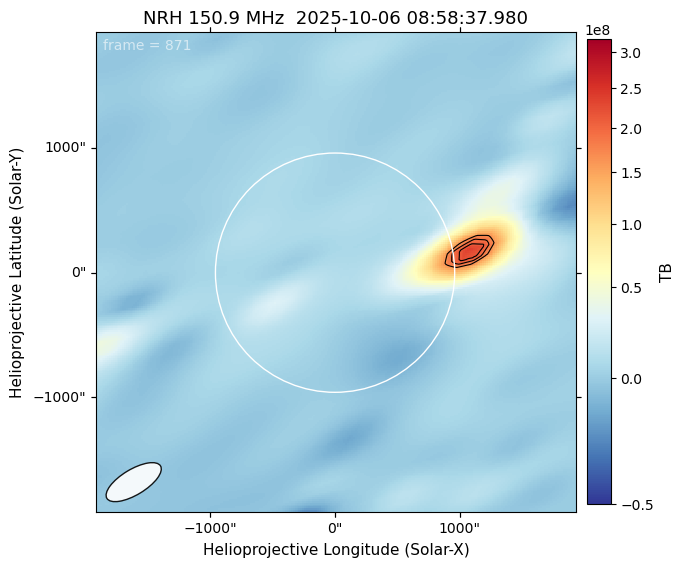

In [50]:
sel_frame = frame_from_time(nrh, TS)
nrh_map   = build_nrh_map(nrh, sel_frame)
print(f'Selected frame {sel_frame}  ({nrh_map.meta["date-obs"]})')

# Global intensity limits for this cube (same scale for all frames)
VMIN, VMAX = cube_vlim(nrh) if GLOBAL_NORM else (None, None)
print(f'vmin={VMIN}, vmax={VMAX}  (norm: {NORM_KIND})')

plot_nrh_map(nrh_map, frame=sel_frame, vmin=VMIN, vmax=VMAX,
             norm_kind=NORM_KIND, levels=CONTOUR_LEVELS, show_beam=True)
plt.tight_layout()
plt.show()

### Colour-normalisation options

`make_norm` builds any of `linear`, `sqrt`, `log`, `power`, `asinh` from the
shared `VMIN`/`VMAX`. Compare a few side by side.


Norm comparison: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  3.32it/s]


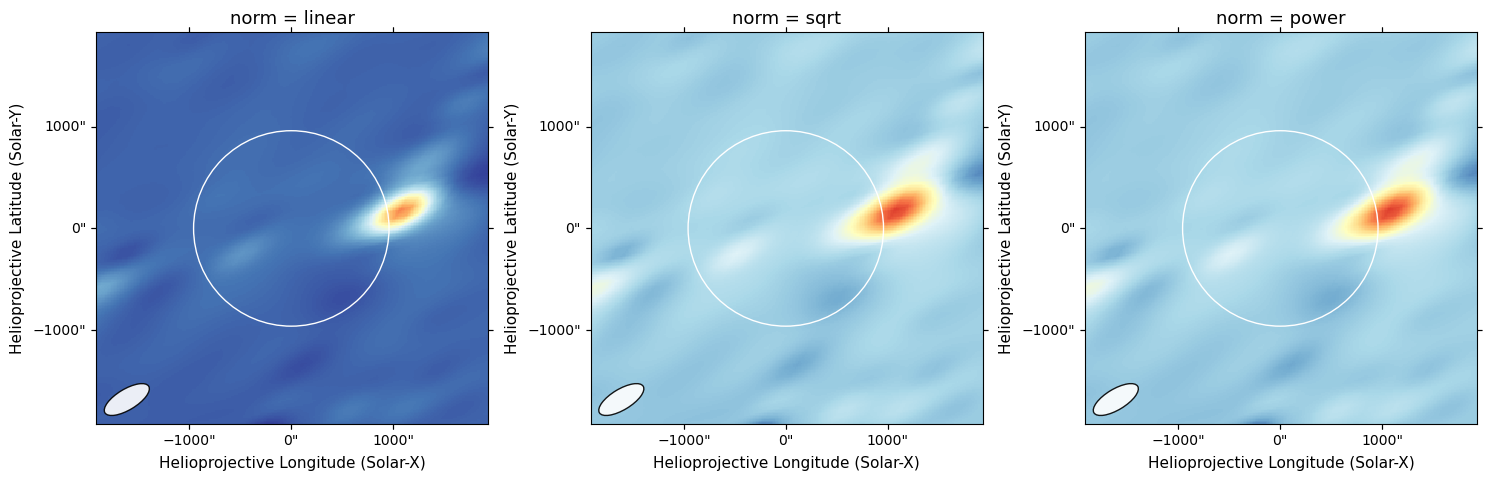

In [52]:
kinds = ['linear', 'sqrt', 'power']
fig = plt.figure(figsize=(5 * len(kinds), 5))
for i, kind in enumerate(tqdm(kinds, desc='Norm comparison')):
    ax = fig.add_subplot(1, len(kinds), i + 1, projection=nrh_map)
    norm = make_norm(kind, VMIN, VMAX, gamma=0.5)
    nrh_map.plot(axes=ax, cmap=CMAP, norm=norm)
    nrh_map.draw_limb(color=LIMB_COLOR)
    if SHOW_BEAM:
        draw_beam(ax, nrh_map)
    ax.grid(False)
    ax.set_title(f'norm = {kind}')
fig.tight_layout()
plt.show()

## 6. Download the matching AIA 193 map

Fetch the AIA image closest to the selected NRH timestamp (`nrh_map`'s
`date-obs`, i.e. the frame nearest `TS`). Needs internet at run time; files are
cached under `savedir/aia`.


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

aia.lev1.193A_2025_10_06T08_58_40.84Z.image_lev1.fits:   0%|          | 0.00/11.9M [00:00<?, ?B/s]

NRH  time: 2025-10-06T08:58:37.980
AIA  time: 2025-10-06T08:58:40.84


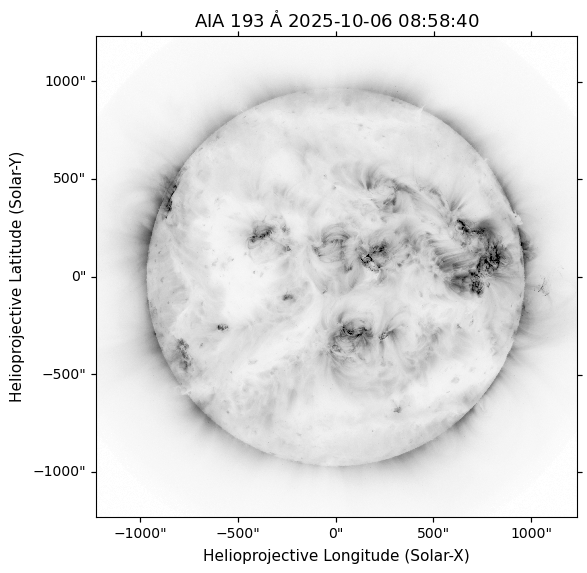

In [53]:
def download_aia(timestamp, channel=AIA_CHANNEL, window=6 * u.s, out_dir=None):
    """Download the AIA map closest to `timestamp` and return it as a sunpy Map."""
    out_dir = out_dir or os.path.join(savedir, 'aia')
    os.makedirs(out_dir, exist_ok=True)
    t = parse_time(timestamp)
    query = Fido.search(a.Time(t - window, t + window),
                        a.Instrument.aia,
                        a.Wavelength(channel * u.angstrom))
    if query.file_num == 0:
        raise RuntimeError(f'No AIA {channel} A files near {timestamp}')
    files = Fido.fetch(query[0,0], site='nso', path=os.path.join(out_dir, '{file}'))
    return sunpy.map.Map(files[0])


# AIA at the SAME timestamp as the selected NRH map
aia_map = download_aia(nrh_map.meta['date-obs'])
print(f"NRH  time: {nrh_map.meta['date-obs']}")
print(f"AIA  time: {aia_map.meta['date-obs']}")

fig = plt.figure(figsize=[6,6])
ax = fig.add_subplot(projection=aia_map)
aia_map.plot_settings['norm'] = ImageNormalize(vmin=0, vmax=4e3, stretch=SqrtStretch())
aia_map.plot(axes=ax, cmap=AIA_CMAP)
ax.grid(False)
fig.tight_layout()
plt.show()

## 7. Overplot NRH contours on AIA


2026-06-26 14:06:04 - reproject.common - INFO: Calling _reproject_full in non-dask mode


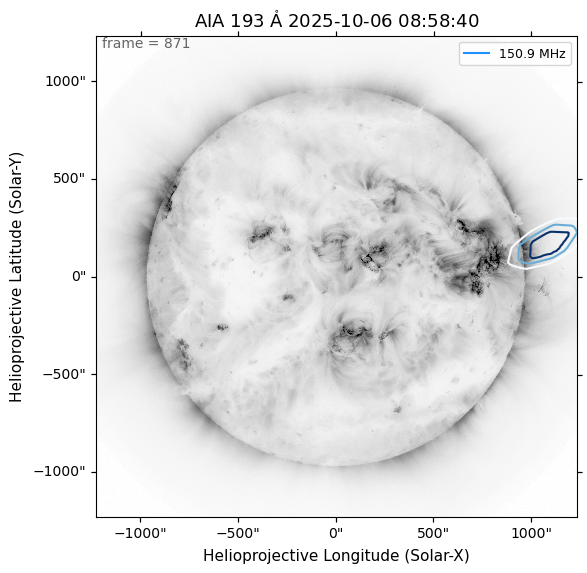

In [54]:
nrh_on_aia = reproject_to_aia(nrh_map, aia_map)

fig = plt.figure(figsize=[6,6])
ax = fig.add_subplot(projection=aia_map)
aia_map.plot(axes=ax, cmap=AIA_CMAP)
nrh_on_aia.draw_contours(axes=ax, levels=CONTOUR_LEVELS, cmap=CONTOUR_CMAP)
ax.text(50, aia_map.data.shape[0] - 100, f'frame = {sel_frame}',
        color='black', fontsize=ANNOT_FONTSIZE, alpha=0.6)
handle = mlines.Line2D([], [], color='dodgerblue',
                       label=f"{nrh_map.meta['wavelnth']} MHz")
ax.legend(handles=[handle])
ax.grid(False)
fig.tight_layout()
plt.show()

### 7b. Contours of several frequencies on one AIA map

One colour per frequency, lowest -> highest.


Overplotting frequencies: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [08:13<00:00, 49.33s/it]


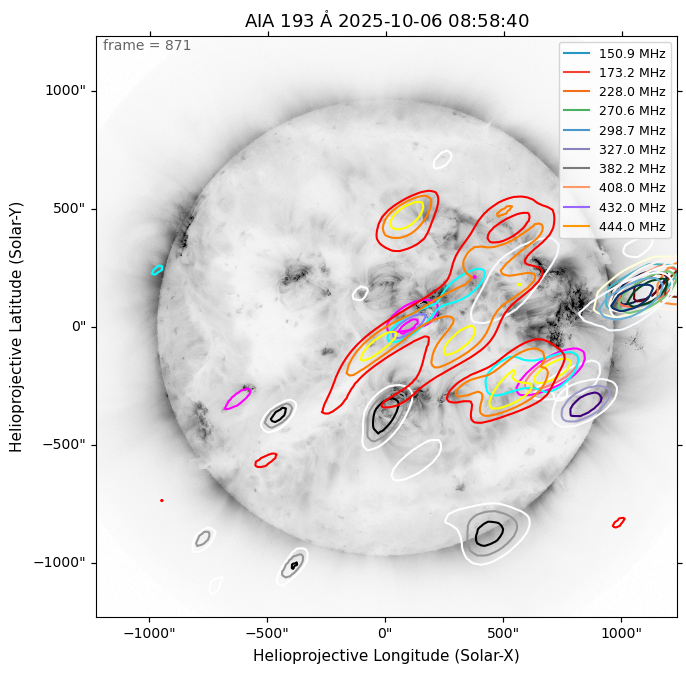

In [55]:
line_colors = {name: cm.get_cmap(name)(0.6) for name in FREQ_CMAPS}
freqs = sorted(maps_by_freq)

fig = plt.figure(figsize=FIGSIZE)
ax = fig.add_subplot(projection=aia_map)
aia_map.plot(axes=ax, cmap=AIA_CMAP)
ax.text(50, aia_map.data.shape[0] - 100, f'frame = {sel_frame}',
        color='black', fontsize=ANNOT_FONTSIZE, alpha=0.6)

handles = []
for i, freq in enumerate(tqdm(freqs, desc='Overplotting frequencies')):
    cmap_name = FREQ_CMAPS[i % len(FREQ_CMAPS)]
    nrh_i = reproject_to_aia(maps_by_freq[freq], aia_map)
    nrh_i.draw_contours(axes=ax, levels=CONTOUR_LEVELS, cmap=cmap_name)
    handles.append(mlines.Line2D([], [], color=line_colors[cmap_name],
                                 label=f'{freq} MHz'))

ax.legend(handles=handles, loc='upper right')
ax.grid(False)
fig.tight_layout()
plt.show()

### 7c. (Optional) Estimate radio-source centroids

Centroid of the 70 % contour per frequency, in arcsec.


In [ ]:
centroids = {}
for freq in tqdm(freqs, desc='Estimating centroids'):
    m = maps_by_freq[freq]
    fig = plt.figure(figsize=FIGSIZE)
    ax = fig.add_subplot(projection=m)
    m.plot(axes=ax, vmin=VMIN, vmax=VMAX, cmap=CMAP)
    with frames.Helioprojective.assume_spherical_screen(m.observer_coordinate):
        c0 = m.draw_contours(axes=ax, levels=70 * u.percent, autoalign=True, colors='black')

    # pick a contour segment (first for the highest band, last otherwise)
    seg = c0.allsegs[0][0] if freq >= 408 else c0.allsegs[0][-1]
    cen = seg.mean(axis=0)                       # centre of mass in pixels
    world = m.pixel_to_world(cen[0] * u.pix, cen[1] * u.pix)
    centroids[freq] = (world.Tx.value, world.Ty.value)
    print(f'{freq:6.1f} MHz: x={world.Tx:.1f}, y={world.Ty:.1f}')

    m.draw_limb(color=LIMB_COLOR)
    ax.grid(False)
    plt.close(fig)   # drop the per-frequency working figure

## 8. Movie of NRH contours over time — single frequency (MP4)

Animate one frequency's NRH contours over time on a fixed AIA background. Frames
are written one by one through `FFMpegWriter.saving(...)` (instead of
`FuncAnimation.save`), which keeps the figure attached to pyplot — this is what
fixes the *"The passed figure is not managed by pyplot"* error that sunpy's
`Map.plot` triggered during `FuncAnimation`. Requires `ffmpeg`.


In [ ]:
def make_single_freq_movie(filename, aia_map, out_path,
                            frame_start=0, frame_end=None, frame_step=None,
                            levels=None, fps=None, contour_cmap=None, dpi=None,
                            axes_rect=None):
    """Write a full-resolution MP4 of one frequency's NRH contours on AIA.

    frame_step=None -> MOVIE_FRAME_STEP (=1, every frame). frame_end=None -> last
    frame. The axes sit on a fixed rectangle so every frame is identical in size.
    """
    frame_step   = frame_step or MOVIE_FRAME_STEP
    levels       = CONTOUR_LEVELS if levels is None else levels
    fps          = fps or MOVIE_FPS
    contour_cmap = contour_cmap or CONTOUR_CMAP
    dpi          = dpi or MOVIE_DPI
    axes_rect    = list(axes_rect or MOVIE_AXES_RECT)

    nrh = load_nrh_sav(filename)
    n_total = len(nrh['nrh_data'])
    frame_end = n_total if frame_end is None else frame_end
    indices = list(range(frame_start, frame_end, frame_step))
    freq = round(float(header_dict(nrh, 0)['FREQ']), 1)

    fig = plt.figure(figsize=FIGSIZE)
    ax = fig.add_axes(axes_rect, projection=aia_map.wcs)   # fixed box -> no jitter
    writer = FFMpegWriter(fps=fps)
    with writer.saving(fig, out_path, dpi):
        for idx in tqdm(indices, desc=f'{freq} MHz movie'):
            ax.clear()
            aia_map.plot(axes=ax, cmap=AIA_CMAP)
            nrh_i = reproject_to_aia(build_nrh_map(nrh, idx), aia_map)
            nrh_i.draw_contours(axes=ax, levels=levels, cmap=contour_cmap)
            ax.set_xlabel('Solar-X (Helioprojective Longitude)')
            ax.set_ylabel('Solar-Y (Helioprojective Latitude)')
            ax.set_title(f"NRH {freq} MHz   {_to_str(header_dict(nrh, idx)['DATE_OBS'])}")
            ax.grid(False)
            writer.grab_frame()
    plt.close(fig)
    print(f'Saved {out_path}  ({len(indices)} frames, dpi={dpi})')
    return out_path


single_movie = os.path.join(savedir, f'nrh_{int(nrh_map.meta["wavelnth"])}MHz_contours.mp4')
make_single_freq_movie(filename, aia_map, single_movie)

## 9. Movie of NRH contours over time — multiple frequencies (MP4)

At each time step, overplot every frequency's contours (one colour each) on the
AIA background. Assumes the channels share the same time sampling.


In [ ]:
def make_multi_freq_movie(freq_files, aia_map, out_path,
                           frame_start=0, frame_end=None, frame_step=None,
                           levels=None, fps=None, dpi=None, axes_rect=None):
    """Write a full-resolution MP4 of all frequencies' NRH contours on AIA."""
    frame_step = frame_step or MOVIE_FRAME_STEP
    levels     = CONTOUR_LEVELS if levels is None else levels
    fps        = fps or MOVIE_FPS
    dpi        = dpi or MOVIE_DPI
    axes_rect  = list(axes_rect or MOVIE_AXES_RECT)

    freqs = sorted(freq_files)
    nrhs  = {freq: load_nrh_sav(freq_files[freq])
             for freq in tqdm(freqs, desc='Loading cubes')}
    n_min = min(len(n['nrh_data']) for n in nrhs.values())
    frame_end = n_min if frame_end is None else min(frame_end, n_min)
    indices = list(range(frame_start, frame_end, frame_step))

    fig = plt.figure(figsize=FIGSIZE)
    ax = fig.add_axes(axes_rect, projection=aia_map.wcs)   # fixed box -> no jitter
    writer = FFMpegWriter(fps=fps)
    with writer.saving(fig, out_path, dpi):
        for idx in tqdm(indices, desc='Multi-frequency movie'):
            ax.clear()
            aia_map.plot(axes=ax, cmap=AIA_CMAP)
            handles = []
            for i, freq in enumerate(freqs):
                cmap_name = FREQ_CMAPS[i % len(FREQ_CMAPS)]
                nrh_i = reproject_to_aia(build_nrh_map(nrhs[freq], idx), aia_map)
                nrh_i.draw_contours(axes=ax, levels=levels, cmap=cmap_name)
                handles.append(mlines.Line2D([], [], color=line_colors[cmap_name],
                                             label=f'{freq} MHz'))
            ax.set_xlabel('Solar-X (Helioprojective Longitude)')
            ax.set_ylabel('Solar-Y (Helioprojective Latitude)')
            ax.set_title(_to_str(header_dict(nrhs[freqs[0]], idx)['DATE_OBS']))
            ax.legend(handles=handles, loc='upper right')
            ax.grid(False)
            writer.grab_frame()
    plt.close(fig)
    print(f'Saved {out_path}  ({len(indices)} frames, dpi={dpi})')
    return out_path


multi_movie = os.path.join(savedir, 'nrh_multifreq_contours.mp4')
make_multi_freq_movie(freq_files, aia_map, multi_movie)

# PNG exporters

Single frequency

In [ ]:
def export_single_freq_frames(filename, aia_map, out_dir,
                              frame_start=0, frame_end=None, frame_step=1,
                              levels=None, contour_cmap=None, dpi=None,
                              axes_rect=None, overwrite=False):
    """Export per-frame PNGs of one frequency's NRH contours on AIA (axes shown)."""
    levels       = CONTOUR_LEVELS if levels is None else levels
    contour_cmap = contour_cmap or CONTOUR_CMAP
    dpi          = dpi or MOVIE_DPI
    axes_rect    = list(axes_rect or MOVIE_AXES_RECT)
    os.makedirs(out_dir, exist_ok=True)

    nrh = load_nrh_sav(filename)
    n_total = len(nrh['nrh_data'])
    frame_end = n_total if frame_end is None else frame_end
    indices = list(range(frame_start, frame_end, frame_step))
    freq = round(float(header_dict(nrh, 0)['FREQ']), 1)
    width = len(str(n_total))

    for idx in tqdm(indices, desc=f'{freq} MHz frames'):
        out_png = os.path.join(out_dir, f'frame_{idx:0{width}d}.png')
        if not overwrite and os.path.exists(out_png):
            continue
        fig = plt.figure(figsize=FIGSIZE)
        ax = fig.add_axes(axes_rect, projection=aia_map)   # WCS axes + fixed box
        aia_map.plot(axes=ax, cmap=AIA_CMAP)
        nrh_i = reproject_to_aia(build_nrh_map(nrh, idx), aia_map)
        nrh_i.draw_contours(axes=ax, levels=levels, cmap=contour_cmap)
        ax.set_xlabel('Solar-X (Helioprojective Longitude)')
        ax.set_ylabel('Solar-Y (Helioprojective Latitude)')
        ax.set_title(f"NRH {freq} MHz   {_to_str(header_dict(nrh, idx)['DATE_OBS'])}")
        ax.grid(False)
        fig.savefig(out_png, dpi=dpi)   # fixed figsize+dpi, no bbox_inches -> identical sizes
        plt.close(fig)
    print(f'Wrote {len(indices)} PNGs to {out_dir}')
    return out_dir


single_dir = os.path.join(savedir, f'frames_{int(nrh_map.meta["wavelnth"])}MHz')
export_single_freq_frames(filename, aia_map, single_dir)

Multiple frequencies

In [ ]:
# One distinct solid colour per frequency so the legend matches the contours exactly.
FREQ_COLORS = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple',
               'tab:brown', 'tab:pink', 'tab:olive', 'tab:cyan', 'tab:gray']


def export_multi_freq_frames(freq_files, aia_map, out_dir,
                             frame_start=0, frame_end=None, frame_step=1,
                             levels=None, dpi=None, axes_rect=None,
                             freq_colors=None, overwrite=False):
    """Export per-frame PNGs with all frequencies' contours on AIA (axes shown)."""
    levels      = CONTOUR_LEVELS if levels is None else levels
    dpi         = dpi or MOVIE_DPI
    axes_rect   = list(axes_rect or MOVIE_AXES_RECT)
    freq_colors = freq_colors or FREQ_COLORS
    os.makedirs(out_dir, exist_ok=True)

    freqs = sorted(freq_files)
    color_for = {freq: freq_colors[i % len(freq_colors)] for i, freq in enumerate(freqs)}

    nrhs  = {freq: load_nrh_sav(freq_files[freq])
             for freq in tqdm(freqs, desc='Loading cubes')}
    n_min = min(len(n['nrh_data']) for n in nrhs.values())
    frame_end = n_min if frame_end is None else min(frame_end, n_min)
    indices = list(range(frame_start, frame_end, frame_step))
    width = len(str(n_min))

    for idx in tqdm(indices, desc='Multi-frequency frames'):
        out_png = os.path.join(out_dir, f'frame_{idx:0{width}d}.png')
        if not overwrite and os.path.exists(out_png):
            continue
        fig = plt.figure(figsize=FIGSIZE)
        ax = fig.add_axes(axes_rect, projection=aia_map)   # WCS axes + fixed box
        aia_map.plot(axes=ax, cmap=AIA_CMAP)
        handles = []
        for freq in freqs:
            c = color_for[freq]
            nrh_i = reproject_to_aia(build_nrh_map(nrhs[freq], idx), aia_map)
            nrh_i.draw_contours(axes=ax, levels=levels, colors=c)
            handles.append(mlines.Line2D([], [], color=c, label=f'{freq} MHz'))
        ax.set_xlabel('Solar-X (Helioprojective Longitude)')
        ax.set_ylabel('Solar-Y (Helioprojective Latitude)')
        ax.set_title(_to_str(header_dict(nrhs[freqs[0]], idx)['DATE_OBS']))
        ax.legend(handles=handles, loc='upper right')
        ax.grid(False)
        fig.savefig(out_png, dpi=dpi)
        plt.close(fig)
    print(f'Wrote {len(indices)} PNGs to {out_dir}')
    return out_dir


multi_dir = os.path.join(savedir, 'frames_multifreq')
export_multi_freq_frames(freq_files, aia_map, multi_dir)

Multi-frequency frames:   0%|                                                                                                                                     | 0/2400 [00:00<?, ?it/s]2026-06-26 15:22:54 - reproject.common - INFO: Calling _reproject_full in non-dask mode
2026-06-26 15:23:43 - reproject.common - INFO: Calling _reproject_full in non-dask mode
2026-06-26 15:24:32 - reproject.common - INFO: Calling _reproject_full in non-dask mode
2026-06-26 15:25:21 - reproject.common - INFO: Calling _reproject_full in non-dask mode
2026-06-26 15:26:11 - reproject.common - INFO: Calling _reproject_full in non-dask mode
Multi-frequency frames:   0%|                                                                                                                        | 1/2400 [04:07<165:10:26, 247.86s/it]2026-06-26 15:27:01 - reproject.common - INFO: Calling _reproject_full in non-dask mode
2026-06-26 15:27:50 - reproject.common - INFO: Calling _reproject_full in non-dask mode
2026-06-26